In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

%matplotlib inline

# ADAPT THIS TO THE FILEPATH OF YOUR PARQUET FILE #
df = pd.read_parquet('diffusion.parquet')

print('shape:', df.shape)
print('columns:   ', df.columns.tolist())
print('heads:     ', sorted(df['heads'].unique()))
print('batch sizes:', sorted(df['batch_size'].unique()))
print('log_lrs:   ', sorted(df['log_lr'].unique()))

shape: (265071, 11)
columns:    ['iteration', 'train/loss', 'val/loss', 'coco_val/loss', 'gns', 'gns_norm', 'gns_var', 'heads', 'log_lr', 'batch_size', 'samples_seen']
heads:      [2, 4, 8]
batch sizes: [64, 128, 256, 512, 1024]
log_lrs:    [-13.0, -12.0, -11.0, -10.0, -9.0]


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
HEADS = 4                       # h2=2, h4=4, h8=8
MAX_EPOCH = 40
IMAGENET_TRAIN_SIZE = 1281167
MAX_IMAGES = MAX_EPOCH * IMAGENET_TRAIN_SIZE
BASE_SMOOTH_BS = 256            # adaptive smoothing threshold

# (batch_size, log_lr, label, color)
selected_configs = [
    (64,   -12.0, r"BS=$2^{6}$, LR=$2^{-12}$", "#0077BB"),
    (128,  -12.0, r"BS=$2^{7}$, LR=$2^{-12}$", "#EE7733"),
    (256,  -11.0, r"BS=$2^{8}$, LR=$2^{-11}$", "#009988"),
    (512,  -10.0, r"BS=$2^{9}$, LR=$2^{-10}$", "#CC3311"),
    (1024, -10.0, r"BS=$2^{10}$, LR=$2^{-10}$", "#EE3377"),
    # different validation loss example
    (1024, -13.0, r"BS=$2^{10}$, LR=$2^{-13}$", "#BBBBBB"),
]

def smooth(values, window):
    if window <= 1:
        return values
    out = np.convolve(values, np.ones(window) / window, mode='valid')
    pad = [np.mean(values[:i+1]) for i in range(len(values) - len(out))]
    return np.concatenate([pad, out])

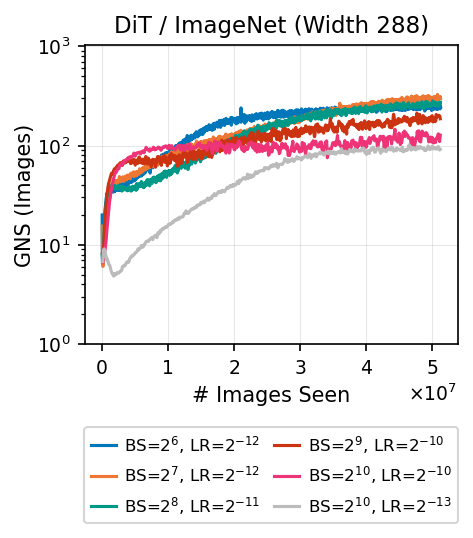

In [ ]:
# ── Plot settings ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'lines.linewidth': 1.5,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

X_COL = 3.25
fig, ax = plt.subplots(figsize=(X_COL, X_COL * 1.21))

for bs, loglr, label, color in selected_configs:
    run = df[
        (df['heads'] == HEADS) &
        (df['batch_size'] == bs) & (df['log_lr'] == loglr) &
        df['gns'].notna() & np.isfinite(df['gns']) & (df['gns'] < 1e6) &
        (df['samples_seen'] <= MAX_IMAGES)
    ].sort_values('samples_seen')

    if run.empty:
        print(f'No data: {label}')
        continue

    window = int(BASE_SMOOTH_BS / bs) if bs < BASE_SMOOTH_BS else 1
    gns = smooth(run['gns'].values, window)

    ax.plot(run['samples_seen'].values, gns, color=color, label=label)

ax.set_xlabel('# Images Seen')
ax.set_ylabel('GNS (Images)', labelpad=1)
ax.set_title('DiT / ImageNet (Width 288)', fontweight='medium')
ax.set_yscale('log')
ax.set_ylim(1, 1024)

ax.xaxis.set_major_locator(FixedLocator([0, 1e7, 2e7, 3e7, 4e7, 5e7]))
ax.xaxis.set_major_formatter(FixedFormatter(['0', '1', '2', '3', '4', '5']))
ax.text(1.0, -0.13, r'$\times 10^7$', transform=ax.transAxes, fontsize=9, ha='right', va='top')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=2, columnspacing=0.8, handlelength=1.5,
          handletextpad=0.5, frameon=True)

fig.tight_layout()
plt.savefig('diffusion_temperature_comparison.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()